# Empirical and density-seeking null-model comparison


In [1]:
from pathlib import Path
import sys

candidates = [Path.cwd(), Path.cwd() / "figure-reproduction", Path.cwd().parent]
repro_dir = next(
    (path.resolve() for path in candidates if (path / "src").is_dir() and (path / "data").is_dir()),
    None,
)
if repro_dir is None:
    raise FileNotFoundError("Run this notebook from the repository, figure-reproduction, or notebooks directory.")
sys.path.insert(0, str(repro_dir / "src"))

from figure_style import (
    DATA_DIR,
    OUTPUT_DIR,
    close_and_report,
    configure_style,
    figure_size,
    finish_axes,
    save_figure,
)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

EXPORT_PROFILE = "final"
configure_style(EXPORT_PROFILE)
np.random.seed(42)

grid = pd.read_parquet(DATA_DIR / "empirical_density_null_comparison.parquet")
helsinki = grid[grid["is_helsinki_region"]].copy()
finland = grid.copy()
EMPIRICAL = "#1B8B8B"
NULL = "#7B5EA7"


def dot_interval(ax, groups, group_names, metrics, ylabel, ylim=None, scatter=False, connect=False):
    x = 0.0
    positions = []
    labels = []
    lines = {}
    for data_group, group_name in zip(groups, group_names):
        start = x
        for column, label, marker, color in metrics:
            values = data_group[column].dropna()
            mean = values.mean()
            q25, q75 = values.quantile([0.25, 0.75])
            if scatter:
                count = max(1, int(len(values) * 0.15))
                sample = values.iloc[np.random.choice(len(values), size=count, replace=False)].to_numpy()
                try:
                    density = gaussian_kde(values.to_numpy())(sample)
                    widths = density / density.max() * 0.045
                except Exception:
                    widths = np.full(count, 0.02)
                jitter = np.array([np.random.normal(x, width) for width in widths])
                ax.scatter(jitter, sample, color=color, alpha=0.13, s=3, edgecolors="none", zorder=1)
            ax.errorbar(
                x, mean, yerr=[[mean - q25], [q75 - mean]],
                fmt=marker, linestyle="none", markersize=5.5,
                color=color, markerfacecolor="white", markeredgewidth=1.2,
                capsize=3.5, capthick=1.1, elinewidth=1.1, zorder=3,
            )
            lines.setdefault(column, [[], [], color])
            lines[column][0].append(x)
            lines[column][1].append(mean)
            x += 0.26
        positions.append(start + 0.13)
        labels.append(group_name)
        x += 0.42
    if connect:
        for xs, means, color in lines.values():
            ax.plot(xs, means, color=color, linewidth=1, alpha=0.7, zorder=2)
    ax.set_xticks(positions, labels)
    ax.set_ylabel(ylabel)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.margins(x=0.14)
    finish_axes(ax)
    ax.grid(False)


legend_handles = [
    Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="white",
           markeredgecolor=EMPIRICAL, markeredgewidth=1.2, markersize=5.5, label="Empirical"),
    Line2D([0], [0], marker="^", linestyle="none", markerfacecolor="white",
           markeredgecolor=NULL, markeredgewidth=1.2, markersize=5.5, label="Null"),
]


rendered pixels: 709 x 561
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_spatial_alignment.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_spatial_alignment.pdf


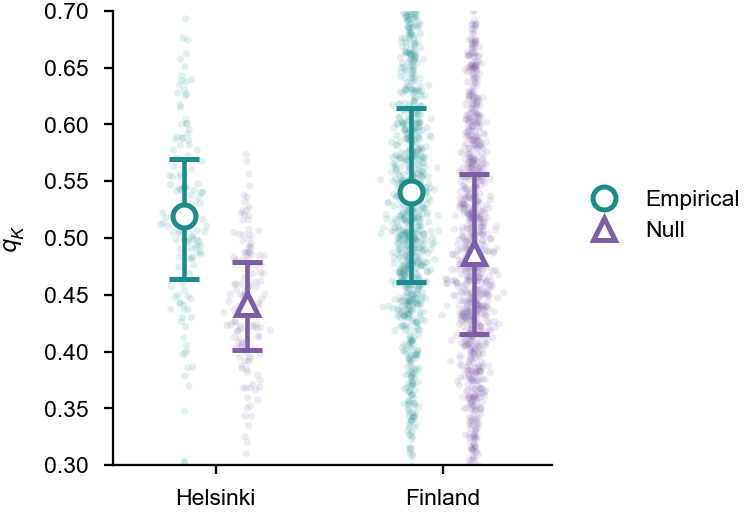

In [3]:
fig, ax = plt.subplots(figsize=figure_size("density_null_alignment"))
fig.subplots_adjust(left=0.16, right=0.78, bottom=0.14, top=0.95)
dot_interval(
    ax, [helsinki, finland], ["Helsinki", "Finland"],
    [("qk_emp", "Empirical", "o", EMPIRICAL), ("qk_null", "Null", "^", NULL)],
    r"$q_K$", ylim=(0.30, 0.70), scatter=True,
)
ax.legend(handles=legend_handles, frameon=False, bbox_to_anchor=(1.02, 0.55), loc="center left")
paths = save_figure(fig, "empirical_density_null_spatial_alignment", EXPORT_PROFILE)
close_and_report(fig, paths)


In [4]:
def draw_metric_panel(metric, title, ylim, log_scale, stem):
    fig, ax = plt.subplots(figsize=figure_size("density_null_metric"))
    fig.subplots_adjust(left=0.24, right=0.97, bottom=0.15, top=0.91)
    freq = finland[
        [f"kfreq_{metric}_weighted_mean_emp", f"kfreq_{metric}_weighted_mean_null_mean"]
    ].rename(columns={
        f"kfreq_{metric}_weighted_mean_emp": "emp",
        f"kfreq_{metric}_weighted_mean_null_mean": "null",
    })
    dist = finland[
        [f"kdist_{metric}_weighted_mean_emp", f"kdist_{metric}_weighted_mean_null_mean"]
    ].rename(columns={
        f"kdist_{metric}_weighted_mean_emp": "emp",
        f"kdist_{metric}_weighted_mean_null_mean": "null",
    })
    dot_interval(
        ax, [freq, dist], [r"$K_{freq}$", r"$K_{dist}$"],
        [("emp", "Empirical", "o", EMPIRICAL), ("null", "Null", "^", NULL)],
        title, ylim=ylim, scatter=False, connect=True,
    )
    if log_scale:
        ax.set_yscale("log")
        ax.set_yticks([20, 30, 40, 60])
        ax.set_yticklabels(["20", "30", "40", "60"])
        ax.minorticks_off()
    elif metric == "poi_diversity":
        ax.set_yticks([0.20, 0.30, 0.40, 0.50, 0.60])
    paths = save_figure(fig, stem, EXPORT_PROFILE)
    close_and_report(fig, paths)


rendered pixels: 354 x 561


saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_poi_diversity.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_poi_diversity.pdf


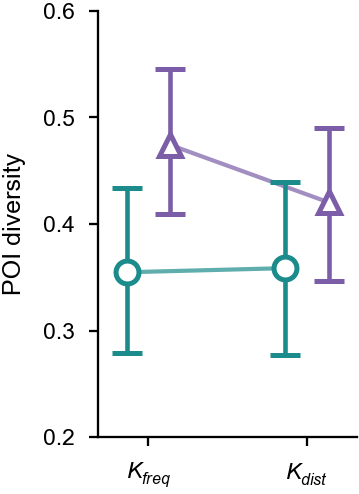

In [5]:
draw_metric_panel("poi_diversity", "POI diversity", (0.20, 0.60), False, "empirical_density_null_poi_diversity")


rendered pixels: 354 x 561
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_poi_count.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_poi_count.pdf


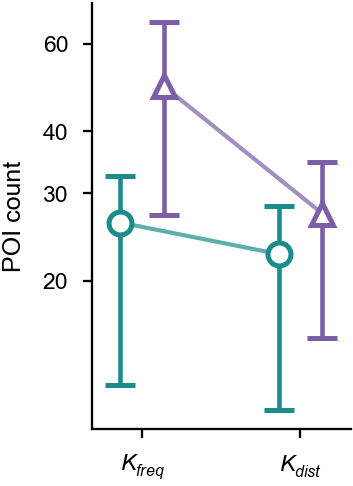

In [6]:
draw_metric_panel("poi_count", "POI count", None, True, "empirical_density_null_poi_count")


rendered pixels: 354 x 561
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_experienced_segregation.png
saved: /Users/silver/.codex/worktrees/4b4b/finland-mobility/figure-reproduction/output/empirical_density_null_experienced_segregation.pdf


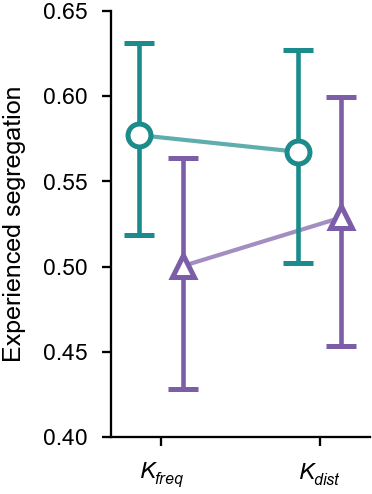

In [7]:
draw_metric_panel("visit_inc_seg", "Experienced segregation", (0.40, 0.65), False, "empirical_density_null_experienced_segregation")
